# Notebook 01 — Aridity at L6: Global and Local Moran's I

**Goal**: Understand spatial autocorrelation from the ground up, using one variable (aridity) at one scale (BasinATLAS Level 6, 16,397 basins). By the end of this notebook you should be able to explain every number and map it produces.

**Variable**: `ari_ix_sav` — UNEP aridity index, local basin. Stored as P/PET × 100 (integer). Low = dry (Sahara ≈ 0–5); high = wet (boreal Canada ≈ 1000+).

**What we'll do**:
1. Load basin geometry + aridity from PostGIS
2. Load the precomputed queen-contiguity weights matrix
3. Compute and interpret **global Moran's I** — one number summarising spatial clustering across all basins
4. Draw the **Moran scatter plot** — the diagnostic behind the number
5. Compute **Local Moran's I (LISA)** — a classification for every basin
6. Map the LISA clusters and compare with the GeoDa reference output

**Validation target**: `spatial/basin06_queen_lisa_ari_x_sav.jpg` — a LISA cluster map produced in GeoDa before this notebook was written. When our map matches it, the machinery is confirmed.

In [1]:
# Cell 2 — imports
%matplotlib inline
import sys
sys.path.insert(0, '/Users/karlg/Documents/repos/_cedop')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

import libpysal
from esda.moran import Moran, Moran_Local

from scripts.shared.db_utils import db_connect

print('Imports OK')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Load data from PostGIS

We need two things from `public.basin06`: the basin geometry (so we can make maps) and the aridity value. We read geometry as WKT text via `ST_AsText()` and convert it to Shapely objects in Python.

`ari_ix_sav`: the `_s` suffix means "local basin" (as opposed to `_u` = upstream catchment). `_av` means average across the basin polygon. This is the value we analyse — no upstream aggregation.

In [2]:
# Cell 4 — load basin geometry + aridity from PostGIS
conn = db_connect()

SQL = """
SELECT hybas_id, ari_ix_sav, ST_AsText(geom) AS geom_wkt
FROM public.basin06
ORDER BY hybas_id
"""

with conn.cursor() as cur:
    cur.execute(SQL)
    rows = cur.fetchall()

conn.close()

df = pd.DataFrame(rows, columns=['hybas_id', 'ari_ix_sav', 'geom_wkt'])
df['geometry'] = df['geom_wkt'].apply(wkt.loads)
df = df.drop(columns='geom_wkt')
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

print(f'{len(gdf):,} basins loaded')
print(f'Missing aridity: {gdf["ari_ix_sav"].isna().sum()}')
gdf[['hybas_id', 'ari_ix_sav']].head()

,hybas_id,ari_ix_sav
0,1.060000e+09,2
1,1.060000e+09,2
2,1.060000e+09,1
3,1.060000e+09,1
4,1.060000e+09,0


## Step 2 — Understand the variable

Before doing any spatial statistics, look at the distribution. This matters because Moran's I measures spatial pattern in the *values*, so understanding the values first gives you a baseline for interpreting the result.

P/PET = precipitation divided by potential evapotranspiration. The UNEP aridity index (×100, stored as integer here) classifies as:
- < 5: hyperarid
- 5–20: arid
- 20–50: semi-arid
- 50–65: dry sub-humid
- > 65: humid

Most of Earth's land surface is dry; expect a right-skewed distribution.

In [3]:
# Cell 7 — aridity distribution (raw and log)
ari = gdf['ari_ix_sav'].dropna().values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ari, bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(65, color='red', linestyle='--', linewidth=1, label='humid threshold (65)')
axes[0].set_xlabel('ari_ix_sav (P/PET × 100)')
axes[0].set_ylabel('Basin count')
axes[0].set_title('Aridity distribution — raw')
axes[0].legend()

ari_log = np.log1p(ari)  # log(1 + x) handles zeros cleanly
axes[1].hist(ari_log, bins=80, color='steelblue', edgecolor='none')
axes[1].set_xlabel('log(1 + ari_ix_sav)')
axes[1].set_ylabel('Basin count')
axes[1].set_title('Aridity distribution — log-transformed')

plt.tight_layout()
plt.show()

print(f'Mean:   {ari.mean():.1f}')
print(f'Median: {np.median(ari):.1f}')
print(f'Max:    {ari.max():.0f}')
print(f'Pct below humid threshold (65): {(ari < 65).mean()*100:.1f}%')

Mean:   84.2
Median: 65.0
Max:    2101
Pct below humid threshold (65): 49.5%


## Step 3 — The spatial weights matrix

Spatial autocorrelation measures whether a basin's value is correlated with its *neighbours'* values. To do that you need a formal definition of "neighbour". That definition is the **spatial weights matrix** W.

**Queen contiguity**: two basins are neighbours if they share any boundary point — edge or corner. Same rule as the queen in chess. It's the most common choice for polygon data.

We build the weights directly from the GeoDataFrame using `Queen.from_dataframe`. This is the correct approach: the weights are keyed by `hybas_id` (the basin primary key), so alignment with the data array is guaranteed. GeoDa can also export weights as `.gal` files, but those carry GeoDa's internal row ordering — a dependency we avoid by computing the weights in Python.

In [4]:
# Cell 9 — build queen contiguity weights directly from GeoDataFrame
# use_index=True keys the weights by hybas_id (the DataFrame index = basin primary key).
# This guarantees alignment with y — no dependency on external row ordering.
# Takes a few minutes at L6 scale (16,397 polygons).

from libpysal.weights import Queen

gdf = gdf.set_index('hybas_id')

w = Queen.from_dataframe(gdf, use_index=True, silence_warnings=True)
w.transform = 'r'

print(f'Basins in weights matrix:  {w.n:,}')
print(f'Mean neighbours per basin: {w.mean_neighbors:.2f}')
print(f'Min neighbours: {w.min_neighbors}   Max: {w.max_neighbors}')
print(f'Key type: {type(w.id_order[0]).__name__}  — first key: {w.id_order[0]}')

Basins in weights matrix:  16,397
Mean neighbours per basin: 5.57
Min neighbours: 0   Max: 19
Key type: float  — first key: 1060000010.0


In [5]:
# Cell 10 — inspect one basin's neighbourhood
# w.id_order[i] is the hybas_id of the i-th observation in the weights matrix.
# Since gdf is indexed by hybas_id and w was built from gdf, they align exactly.

EXAMPLE_IDX = 500
w_key          = w.id_order[EXAMPLE_IDX]   # hybas_id integer
neighbour_keys = w.neighbors[w_key]

print(f'gdf position (0-based):        {EXAMPLE_IDX}')
print(f'hybas_id (w key):              {w_key}  (type: {type(w_key).__name__})')
print(f'Number of queen neighbours:    {len(neighbour_keys)}')
print(f'Neighbour hybas_ids:           {list(neighbour_keys)[:8]}')
print(f'Weights (row-standardised):    {[round(x,4) for x in list(w.weights[w_key])[:8]]}')
print()
print('Each weight = 1 / number_of_neighbours (row-standardised).')
print("Spatial lag = simple average of neighbours' values.")

gdf position (0-based):        500
hybas_id (w key):              1060040480.0  (type: float)
Number of queen neighbours:    11
Neighbour hybas_ids:           [1060045150.0, 1060055170.0, 1060051330.0, 1060041610.0, 1060040690.0, 1060046750.0, 1060032180.0, 1060042680.0]
Weights (row-standardised):    [0.0909, 0.0909, 0.0909, 0.0909, 0.0909, 0.0909, 0.0909, 0.0909]

Each weight = 1 / number_of_neighbours (row-standardised).
Spatial lag = simple average of neighbours' values.


## Step 4 — Global Moran's I

**Global Moran's I** asks: across all basins, is a basin's aridity correlated with the average aridity of its neighbours? If yes and positive: similar values cluster together (high near high, low near low). If negative: high values are systematically surrounded by low values (a checkerboard pattern, rare in nature).

The formula is:

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

In plain terms: it is the slope of a regression of each basin's standardised value on the spatially-weighted average of its neighbours' standardised values.

**Expected value under no spatial pattern**: I ≈ −1/(n−1) ≈ 0 for large n.

**Range**: roughly −1 (perfect dispersion) to +1 (perfect clustering). Values above ~0.3 are considered strongly clustered for geographic data.

**P-value**: computed by permutation — shuffle the values across basins, recompute I, repeat 999 times, see how extreme the real I is. We fix `seed=42` so the result is reproducible.

In [6]:
# Cell 12 — compute global Moran's I
assert len(gdf) == w.n, f'Row count mismatch: gdf={len(gdf)}, w={w.n}'

y = gdf['ari_ix_sav'].values.astype(float)

np.random.seed(42)
mi = Moran(y, w, permutations=999)

print(f"Moran's I:  {mi.I:.4f}")
print(f'Expected I: {mi.EI:.6f}  (theoretical value under spatial randomness)')
print(f'p-value:    {mi.p_sim:.4f}  (from {mi.permutations} permutations)')
print(f'z-score:    {mi.z_sim:.2f}')
print()
print('Interpretation:')
print(f'  I={mi.I:.3f} >> 0  →  strong positive spatial autocorrelation')
print(f'  p={mi.p_sim:.4f}   →  result is almost certainly not random')

Moran's I:  0.9628
Expected I: -0.000061  (theoretical value under spatial randomness)
p-value:    0.0010  (from 999 permutations)
z-score:    195.64

Interpretation:
  I=0.963 >> 0  →  strong positive spatial autocorrelation
  p=0.0010   →  result is almost certainly not random


## Step 5 — The Moran scatter plot

The global I is a single number. The **Moran scatter plot** is the diagnostic that shows you what it means spatially.

- **X-axis**: each basin's standardised aridity value (z-score: how far above/below the mean)
- **Y-axis**: the spatially lagged value — the weighted average of that basin's neighbours' z-scores
- **Slope of the regression line** = Moran's I

The four quadrants correspond directly to the LISA categories:
- **Upper-right (HH)**: high value basin, high-value neighbours — cluster core
- **Lower-left (LL)**: low value basin, low-value neighbours — cluster core
- **Upper-left (LH)**: low value basin, high-value neighbours — spatial outlier
- **Lower-right (HL)**: high value basin, low-value neighbours — spatial outlier

When most points fall in HH and LL (the concordant quadrants), the slope is steep and I is high.

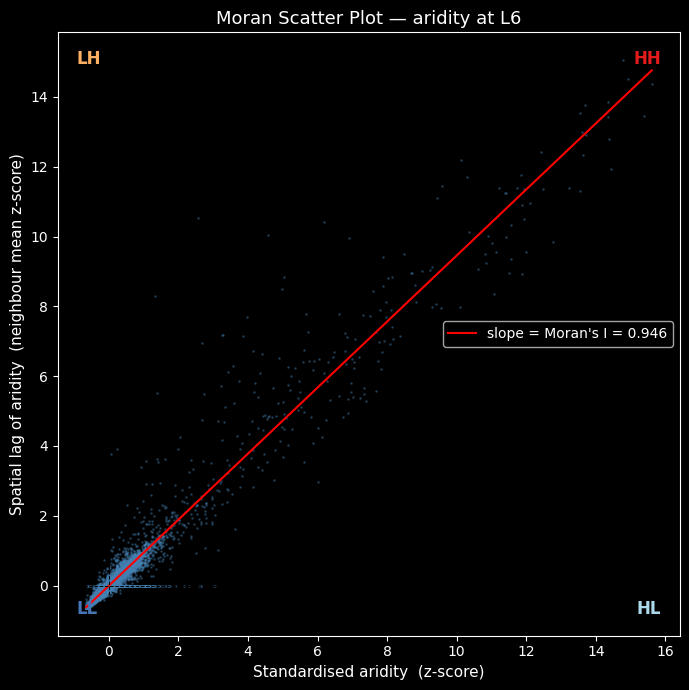

In [7]:
# Cell 14 — Moran scatter plot
y_std = (y - y.mean()) / y.std()
wy    = libpysal.weights.lag_spatial(w, y_std)

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_std, wy, s=1, alpha=0.3, color='steelblue')

m, b = np.polyfit(y_std, wy, 1)
x_line = np.linspace(y_std.min(), y_std.max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5,
        label=f"slope = Moran's I = {m:.3f}")

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.axvline(0, color='black', linewidth=0.7, linestyle='--')

ax.text(0.97, 0.97, 'HH', transform=ax.transAxes, ha='right', va='top',    fontsize=12, color='#e41a1c', fontweight='bold')
ax.text(0.03, 0.97, 'LH', transform=ax.transAxes, ha='left',  va='top',    fontsize=12, color='#fdae61', fontweight='bold')
ax.text(0.97, 0.03, 'HL', transform=ax.transAxes, ha='right', va='bottom', fontsize=12, color='#abd9e9', fontweight='bold')
ax.text(0.03, 0.03, 'LL', transform=ax.transAxes, ha='left',  va='bottom', fontsize=12, color='#4575b4', fontweight='bold')

ax.set_xlabel('Standardised aridity  (z-score)', fontsize=11)
ax.set_ylabel('Spatial lag of aridity  (neighbour mean z-score)', fontsize=11)
ax.set_title("Moran Scatter Plot — aridity at L6", fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
print(f'Regression slope (should equal Moran I): {m:.4f}')
print(f"Moran's I from esda:                     {mi.I:.4f}")
# fig


print(f'Regression slope (should equal Moran I): {m:.4f}')
print(f"Moran's I from esda:                     {mi.I:.4f}")

## Step 6 — Local Moran's I (LISA)

Global Moran's I tells you *that* clustering exists. **Local Indicators of Spatial Association (LISA)** tell you *where*. The global statistic is the sum of local ones:

$$I_i = z_i \sum_j w_{ij} z_j$$

where $z_i$ is the standardised value at basin $i$. Each basin gets:
- A **local I value** — its individual contribution to global clustering
- A **p-value** — significance via permutation (neighbours are shuffled, not all basins)
- A **quadrant label** — which of the four Moran plot quadrants it falls in

The quadrant label only means something if the basin is *statistically significant* (p < 0.05). Non-significant basins are classed **NS** regardless of quadrant — they may be in any quadrant by chance.

The four significant classes for aridity:
- **HH** — humid, surrounded by humid: a cluster core in the wet direction
- **LL** — dry, surrounded by dry: a cluster core in the arid direction
- **HL** — humid outlier in an arid neighbourhood (e.g. Nile valley in the Sahara)
- **LH** — arid outlier in a humid neighbourhood (e.g. rain-shadow basin in otherwise wet region)

In [8]:
# Cell 16 — compute LISA (local Moran's I)
np.random.seed(42)
lisa = Moran_Local(y, w, permutations=999)

# lisa.q: quadrant code per basin  (1=HH, 2=LH, 3=LL, 4=HL)
# lisa.p_sim: permutation p-value per basin

SIGNIFICANCE = 0.05
quad_map = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

labels = np.where(
    lisa.p_sim < SIGNIFICANCE,
    np.array([quad_map[q] for q in lisa.q]),
    'NS'
)

gdf['lisa_class'] = labels
gdf['lisa_p']     = lisa.p_sim
gdf['lisa_I']     = lisa.Is

counts = pd.Series(labels).value_counts().reindex(['HH', 'LL', 'HL', 'LH', 'NS'], fill_value=0)
print('LISA classification counts (p < 0.05):')
for cls, n in counts.items():
    print(f'  {cls}: {n:5,}  ({n / len(gdf) * 100:.1f}%)')
print(f'\n  Total significant: {(labels != "NS").sum():,}  ({(labels != "NS").mean()*100:.1f}%)')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


## Step 7 — Map the LISA clusters

Now render the classification spatially. The colour scheme matches GeoDa's defaults, making direct comparison with `spatial/basin06_queen_lisa_ari_x_sav.jpg` straightforward.

GeoDa convention (standard):
- **Red** = HH — high aridity (humid) cluster cores
- **Blue** = LL — low aridity (dry/arid) cluster cores
- **Orange/pink** = LH — dry outlier in humid surroundings
- **Light blue** = HL — humid outlier in dry surroundings
- **Light grey** = NS — not significant at p < 0.05

Note: because `ari_ix_sav` is a *humidity* index (high = wet), the large blue clusters over the Sahara, Arabia, and Australia are **LL** (low humidity surrounded by low humidity = arid cores). The red clusters over boreal Canada and Scandinavia are **HH** (high humidity surrounded by high humidity = wet cores).

In [9]:
# Cell 18 — LISA cluster map
COLOURS = {
    'HH': '#e41a1c',
    'LL': '#4575b4',
    'LH': '#fdae61',
    'HL': '#abd9e9',
    'NS': '#d9d9d9',
}

fig, ax = plt.subplots(figsize=(16, 9))

gdf[gdf['lisa_class'] == 'NS'].plot(ax=ax, color=COLOURS['NS'], linewidth=0)
for cls in ['LL', 'HH', 'HL', 'LH']:
    subset = gdf[gdf['lisa_class'] == cls]
    if len(subset):
        subset.plot(ax=ax, color=COLOURS[cls], linewidth=0)

legend_entries = {
    'HH — humid cluster core':                COLOURS['HH'],
    'LL — arid cluster core':                 COLOURS['LL'],
    'LH — dry outlier in humid surroundings': COLOURS['LH'],
    'HL — humid outlier in dry surroundings': COLOURS['HL'],
    'NS — not significant':                   COLOURS['NS'],
}
patches = [mpatches.Patch(color=c, label=l) for l, c in legend_entries.items()]
ax.legend(handles=patches, loc='lower left', fontsize=9, framealpha=0.9)

ax.set_title(
    f'LISA Cluster Map — Aridity (ari_ix_sav) at L6\n'
    f'Queen contiguity · 999 permutations · p < {SIGNIFICANCE}',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.savefig('/Users/karlg/Documents/repos/_cedop/spatial/basin06_queen_lisa_ari_python.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → spatial/basin06_queen_lisa_ari_python.png')

Saved → spatial/basin06_queen_lisa_ari_python.png


## Step 8 — Compare with the GeoDa reference

Open `spatial/basin06_queen_lisa_ari_x_sav.jpg` alongside the map above. The major cluster regions should match:

| Region | Expected class | Why |
|---|---|---|
| Sahara, Arabian Peninsula | LL (blue) | Very low P/PET, surrounded by same |
| Central Asia, Gobi | LL (blue) | Continental arid core |
| Australia interior | LL (blue) | Outback aridity cluster |
| Atacama / coastal Peru | LL (blue) | Extreme hyperarid |
| Canadian boreal / Arctic | HH (red) | Very high P/PET, surrounded by same |
| Scandinavia / N. Europe | HH (red) | Humid maritime and boreal |
| Patagonia | HH (red) | Southern hemisphere wet cluster |
| Nile valley in Sahara | HL (light blue) | Humid corridor in arid surroundings |

If the map matches the GeoDa reference: the PySAL implementation is confirmed and we can proceed to the full characterisation pipeline.

If it doesn't match: most likely cause is a row-order mismatch between `gdf` and the weights matrix. The `assert len(gdf) == w.n` check above catches size mismatches but not ordering mismatches.

In [10]:
# Cell 20 — characterisation summary (prototype row for variable_characterization.csv)
n_total = len(gdf)
hh_pct  = (gdf['lisa_class'] == 'HH').sum() / n_total * 100
ll_pct  = (gdf['lisa_class'] == 'LL').sum() / n_total * 100
hl_pct  = (gdf['lisa_class'] == 'HL').sum() / n_total * 100
lh_pct  = (gdf['lisa_class'] == 'LH').sum() / n_total * 100

print('=== Characterisation summary — ari_ix_sav, L6, queen contiguity, raw values ===')
print(f"Global Moran's I:        {mi.I:.4f}")
print(f'p-value (999 perms):     {mi.p_sim:.4f}')
print(f'Cluster-core % (HH+LL):  {hh_pct + ll_pct:.1f}%')
print(f'Outlier % (HL+LH):       {hl_pct + lh_pct:.1f}%')
print(f'Not significant:         {(gdf["lisa_class"] == "NS").sum() / n_total * 100:.1f}%')
print()
print('This row is the prototype for variable_characterization.csv.')

=== Characterisation summary — ari_ix_sav, L6, queen contiguity, raw values ===
Global Moran's I:        0.9628
p-value (999 perms):     0.0010
Cluster-core % (HH+LL):  34.6%
Outlier % (HL+LH):       1.4%
Not significant:         64.0%

This row is the prototype for variable_characterization.csv.


## Step 9 — Sensitivity check: log transform

The characterisation pipeline will apply `log(1 + x)` to right-skewed variables before computing spatial statistics. For aridity, the raw distribution is heavily right-skewed — mostly dry basins, long tail of very wet.

This cell reruns Moran's I on log-transformed values. If I is similar, the raw and log results agree: the spatial structure is dominated by the large arid/humid clusters regardless of how we scale the values. If I differs substantially, the long wet tail is driving the global statistic and the log version is more reliable.

This kind of check should be documented in the characterisation report for any right-skewed variable.

In [11]:
# Cell 22 — sensitivity check: log transform
y_log  = np.log1p(y)
np.random.seed(42)
mi_log = Moran(y_log, w, permutations=999)

print('=== Sensitivity: log(1 + ari_ix_sav) ===')
print(f"Moran's I (raw):             {mi.I:.4f}")
print(f"Moran's I (log-transformed): {mi_log.I:.4f}")
print(f'Absolute difference:         {abs(mi.I - mi_log.I):.4f}')
print()
if abs(mi.I - mi_log.I) < 0.05:
    print('→ Transform makes little difference to the global statistic.')
    print('  The spatial clustering structure is robust to distributional skew.')
    print('  The pipeline will use log-transformed values as canonical')
    print('  (more normally distributed input = better-behaved permutation tests).')
else:
    print('→ Transform changes I noticeably — document which version is canonical')
    print('  and why, before running the full pipeline.')

=== Sensitivity: log(1 + ari_ix_sav) ===
Moran's I (raw):             0.9628
Moran's I (log-transformed): 0.9731
Absolute difference:         0.0104

→ Transform makes little difference to the global statistic.
  The spatial clustering structure is robust to distributional skew.
  The pipeline will use log-transformed values as canonical
  (more normally distributed input = better-behaved permutation tests).
